# Espacios de color aplicados a visión por ordenador

**Objetivo.** Explorar y comparar los espacios RGB, HSV, CIELAB (Lab), YCrCb, escala de grises/binario y XYZ. Para cada uno se realiza una conversión con OpenCV, se visualizan sus componentes y se documentan aplicaciones habituales.

> OpenCV lee las imágenes en orden **BGR**. Cuando una imagen se muestra con Matplotlib se convierte previamente a **RGB**.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATA = Path('data')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 12

print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)

OpenCV: 4.13.0
NumPy: 2.3.5


## 1. RGB

**Definición.** RGB es un modelo aditivo que representa cada píxel mediante tres componentes: rojo (R), verde (G) y azul (B). Es el formato natural de cámaras, monitores y muchas imágenes digitales.

**Imagen elegida.** La fotografía de frutas contiene colores muy variados e intensos, por lo que permite observar con claridad cómo cambia la contribución de cada canal.

**Casos de uso.** Visualización de imágenes, adquisición mediante cámaras, procesamiento general, clasificación de imágenes y entrada habitual de redes neuronales convolucionales.

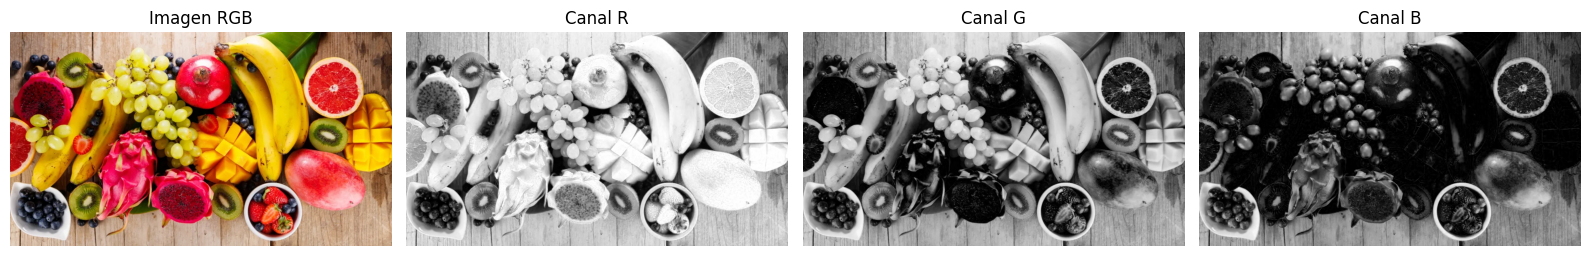

In [2]:
img_bgr = cv2.imread(str(DATA / 'colores.png'))
if img_bgr is None:
    raise FileNotFoundError('No se pudo cargar data/colores.png')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
r, g, b = cv2.split(img_rgb)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Imagen RGB')
ax[1].imshow(r, cmap='gray'); ax[1].set_title('Canal R')
ax[2].imshow(g, cmap='gray'); ax[2].set_title('Canal G')
ax[3].imshow(b, cmap='gray'); ax[3].set_title('Canal B')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 2. HSV

**Definición.** HSV separa el color en **H** (Hue, tono), **S** (Saturation, saturación) y **V** (Value, brillo). Esta separación hace que el tono pueda analizarse de manera más independiente de la intensidad luminosa.

**Imagen elegida.** El balón aparece sobre un césped verde muy dominante. Es un buen ejemplo para explicar cómo el componente de tono puede ayudar a separar regiones de color.

**Casos de uso.** Segmentación por color, seguimiento de objetos, detección de señales u objetos con colores conocidos y análisis de imágenes donde interesa reducir la influencia del brillo.

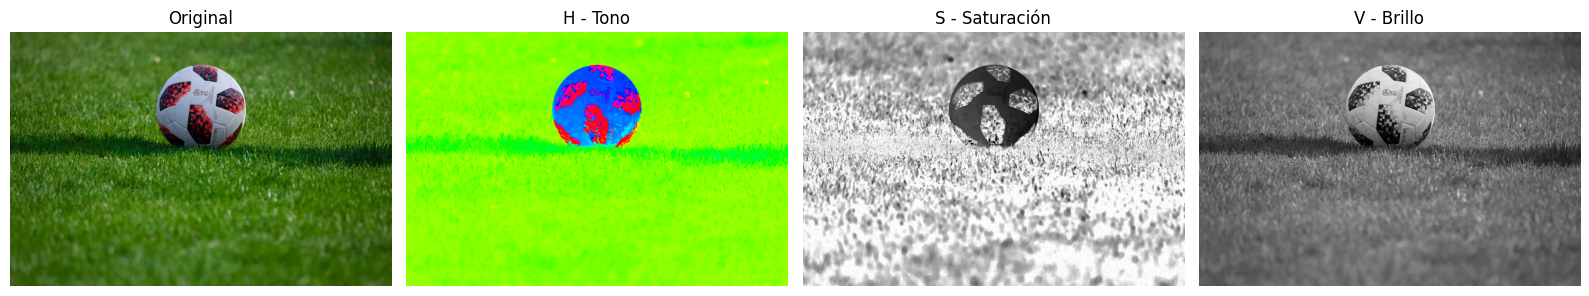

In [3]:
img_bgr = cv2.imread(str(DATA / 'objeto_color.png'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Original')
ax[1].imshow(h, cmap='hsv'); ax[1].set_title('H - Tono')
ax[2].imshow(s, cmap='gray'); ax[2].set_title('S - Saturación')
ax[3].imshow(v, cmap='gray'); ax[3].set_title('V - Brillo')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 3. CIELAB (Lab)

**Definición.** CIELAB separa aproximadamente la luminosidad de la cromaticidad. **L\*** representa la luminosidad; **a\*** describe el eje verde-rojo y **b\*** el eje azul-amarillo. Fue diseñado para que diferencias numéricas representen, de forma aproximada, diferencias perceptuales.

**Imagen elegida.** La escena urbana nocturna combina zonas oscuras con luces muy intensas y colores cálidos/fríos, por lo que permite apreciar la utilidad de separar luminosidad y cromaticidad.

**Casos de uso.** Corrección de iluminación y color, comparación perceptual de colores, mejora de contraste, análisis industrial de color y preprocesado para segmentación.

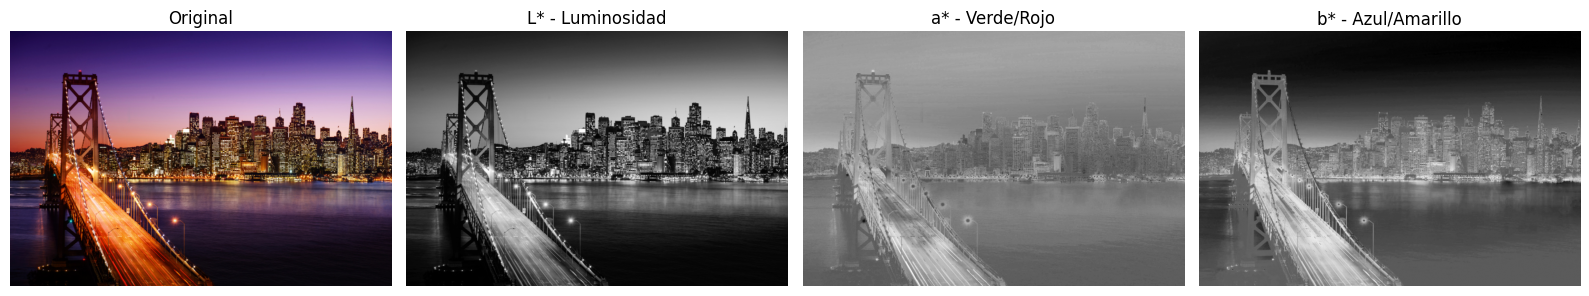

In [4]:
img_bgr = cv2.imread(str(DATA / 'iluminacion.png'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l, a_ch, b_ch = cv2.split(lab)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Original')
ax[1].imshow(l, cmap='gray'); ax[1].set_title('L* - Luminosidad')
ax[2].imshow(a_ch, cmap='gray'); ax[2].set_title('a* - Verde/Rojo')
ax[3].imshow(b_ch, cmap='gray'); ax[3].set_title('b* - Azul/Amarillo')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 4. YCrCb

**Definición.** YCrCb separa la señal en **Y** (luminancia) y dos componentes de crominancia, **Cr** y **Cb**. Esta separación es muy útil en sistemas de imagen y vídeo porque el ojo humano es más sensible a la luminancia que a pequeñas variaciones de crominancia.

**Imagen elegida.** Se usa un retrato porque YCrCb aparece frecuentemente en procesamiento de vídeo, compresión y algoritmos que separan información de luminancia y color en rostros.

**Casos de uso.** Compresión JPEG/vídeo, transmisión de televisión, procesamiento de vídeo, análisis de crominancia y determinados métodos de detección de regiones de piel.

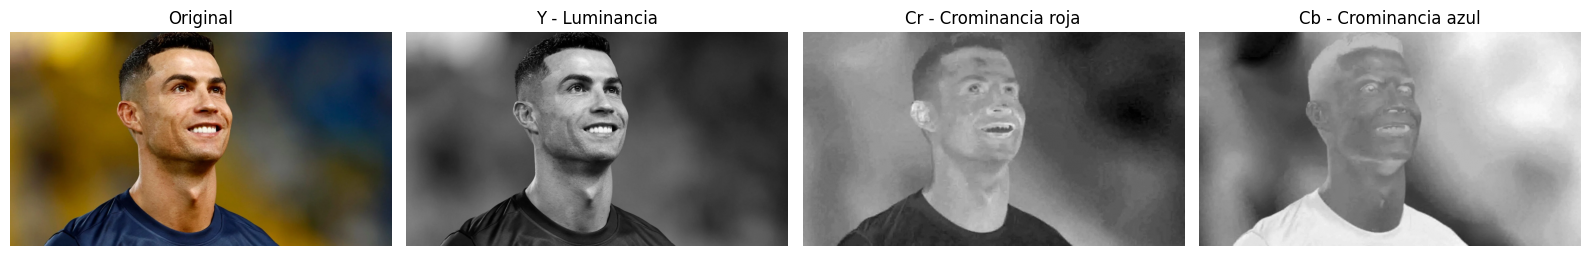

In [5]:
img_bgr = cv2.imread(str(DATA / 'persona.png'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
y, cr, cb = cv2.split(ycrcb)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Original')
ax[1].imshow(y, cmap='gray'); ax[1].set_title('Y - Luminancia')
ax[2].imshow(cr, cmap='gray'); ax[2].set_title('Cr - Crominancia roja')
ax[3].imshow(cb, cmap='gray'); ax[3].set_title('Cb - Crominancia azul')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 5. Escala de grises e imagen binaria

**Definición.** Una imagen en escala de grises utiliza un único valor de intensidad por píxel. Una imagen binaria reduce la representación a dos valores, normalmente negro y blanco, mediante un umbral.

**Imagen elegida.** Un código QR está formado por patrones oscuros y claros de alto contraste. Por ello es un ejemplo directo de una tarea donde el color suele ser innecesario.

**Casos de uso.** Lectura de QR y códigos de barras, OCR, detección de bordes, segmentación sencilla, inspección documental y reducción del coste computacional.

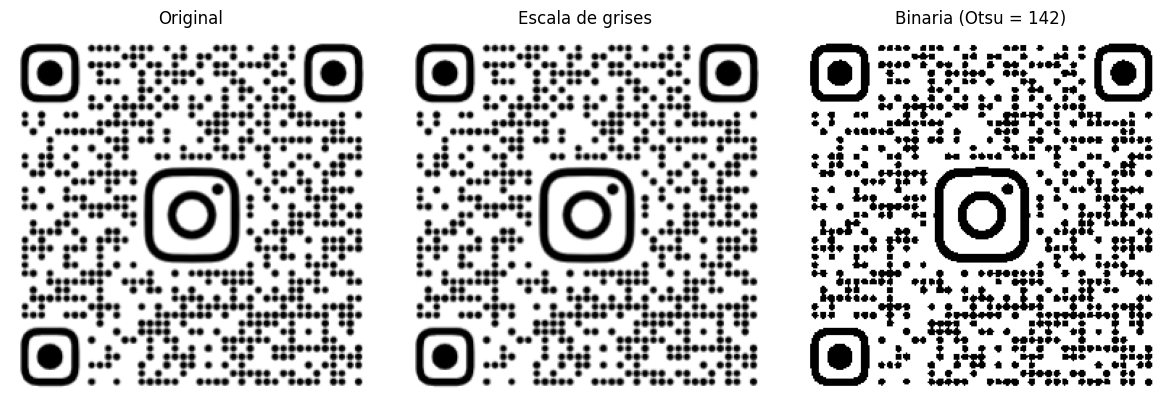

In [6]:
img_bgr = cv2.imread(str(DATA / 'qr.png'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
threshold, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Original')
ax[1].imshow(gray, cmap='gray'); ax[1].set_title('Escala de grises')
ax[2].imshow(binary, cmap='gray'); ax[2].set_title(f'Binaria (Otsu = {threshold:.0f})')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 6. XYZ

**Definición.** CIE XYZ es un espacio de color independiente del dispositivo definido a partir de la respuesta visual humana. Los valores X, Y y Z actúan como componentes de referencia; la componente Y está relacionada con la luminancia. Muchos otros espacios, como Lab, se definen a partir de XYZ.

**Imagen elegida.** Se reutiliza la fotografía de frutas para comparar una imagen rica en colores con un espacio de referencia más orientado a colorimetría que a visualización directa.

**Casos de uso.** Colorimetría, gestión de color, conversión entre espacios, calibración de dispositivos y base matemática para otros espacios como CIELAB.

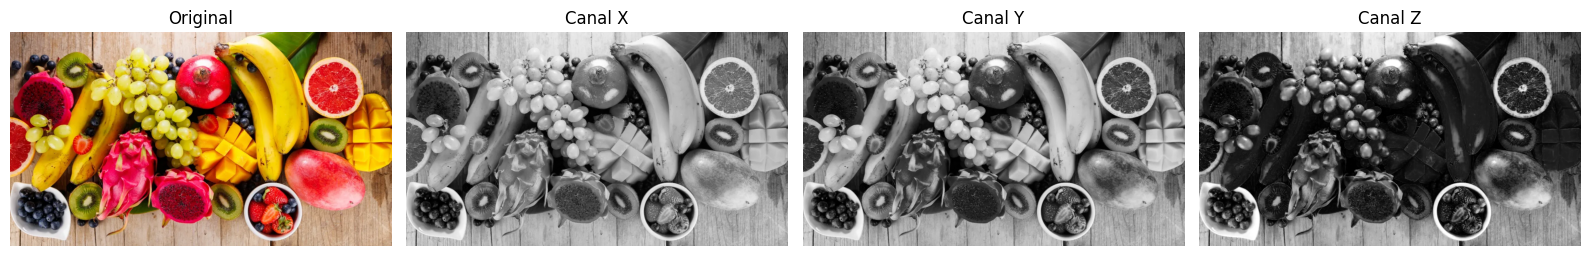

In [7]:
img_bgr = cv2.imread(str(DATA / 'colores.png'))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
xyz = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2XYZ)
x, y, z = cv2.split(xyz)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb); ax[0].set_title('Original')
ax[1].imshow(x, cmap='gray'); ax[1].set_title('Canal X')
ax[2].imshow(y, cmap='gray'); ax[2].set_title('Canal Y')
ax[3].imshow(z, cmap='gray'); ax[3].set_title('Canal Z')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 7. Comparación final

| Espacio | Componentes | Ventaja principal | Ejemplos de aplicación |
|---|---|---|---|
| RGB | R, G, B | Representación directa de cámaras/pantallas | Visualización, redes neuronales, procesamiento general |
| HSV | H, S, V | Separa tono y brillo | Segmentación y seguimiento por color |
| Lab | L*, a*, b* | Separa luminosidad y cromaticidad, orientación perceptual | Corrección de color, contraste, inspección |
| YCrCb | Y, Cr, Cb | Separa luminancia y crominancia | JPEG, vídeo, procesamiento de rostros |
| Gris/binario | Intensidad / 0-1 | Menor complejidad | QR, OCR, bordes, documentos |
| XYZ | X, Y, Z | Referencia colorimétrica independiente del dispositivo | Calibración, conversiones, base de Lab |

### Conclusión

No existe un espacio de color universalmente mejor. La elección depende del problema. RGB es natural para visualizar y capturar imágenes; HSV facilita trabajar con tonos; Lab y YCrCb separan información luminosa y cromática con objetivos distintos; el gris/binario elimina información innecesaria cuando solo importa la estructura; y XYZ funciona como referencia de colorimetría y transformación entre espacios.